<a href="https://colab.research.google.com/github/KianBaghai/emg2qwerty/blob/main/channel_count_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experimentation of channel count vs CER

Using the CNN + GRU with 2 GRU layers and 0.1 dropout with 50 epochs as a baseline model, we now want to explore how channel dropout affects CER. To do so, we created a channelMask class in transforms.py and changed the transforms yaml file accordingly. Now, we can specific the channels we want to include, and can compare how the CER changes as we adjust the number of channels included.

### mount google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### open project repo and pull changes

In [ ]:
%cd /content/drive/MyDrive/emg2qwerty

/content/drive/MyDrive/emg2qwerty


In [ ]:
!rm /content/drive/MyDrive/emg2qwerty/.git/index.lock # sometimes necessary step
!git pull

/content/drive/MyDrive/emg2qwerty
rm: cannot remove '/content/drive/MyDrive/emg2qwerty/.git/index.lock': No such file or directory
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 0), reused 0 (delta 0), pack-reused 3 (from 1)
Unpacking objects: 100% (8/8), 8.13 KiB | 18.00 KiB/s, done.
From https://github.com/KianBaghai/emg2qwerty
   b515d6a..6db0728  main       -> origin/main
Updating b515d6a..6db0728
Fast-forward
 config/model/conv_bilstm_ctc.yaml | 17 +++++++++++++++++
 config/model/conv_rnn_ctc.yaml    |  1 +
 emg2qwerty/lightning.py           |  8 +++++++-
 emg2qwerty/modules.py             |  6 +++++-
 4 files changed, 30 insertions(+), 2 deletions(-)
 create mode 100644 config/model/conv_bilstm_ctc.yaml
fatal: cannot exec '.git/hooks/post-merge': Permission denied


### Install requirements

In [ ]:
%pip install -r requirements.txt

  Using cached https://github.com/kpu/kenlm/archive/master.zip (553 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


BASELINE PERFORMANCE: When using all 16 channels: val/CER = 21.95, ~24 min to train


For compute sake, will not be rerunning this result

## TEST 1: Use every other channel (8 channels)

In [ ]:
!python -m emg2qwerty.train \
    model=conv_rnn_ctc \
    module.rnn_layers=2 \
    module.dropout=0.1 \
    channel_mask.keep=[0,2,4,6,8,10,12,14] \
    module.rnn_type=gru \
    user=single_user \
    trainer.accelerator=gpu trainer.devices=1 \
    trainer.max_epochs=50

[2026-03-07 23:17:17,369][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

also ~24 minutes to trai, val CER = 23.03

## TEST 2: Use four channels, evenly spaced apart (0, 4, 8, 12)

In [ ]:
!python -m emg2qwerty.train \
    model=conv_rnn_ctc \
    module.rnn_layers=2 \
    module.dropout=0.1 \
    channel_mask.keep=[0,4,8,12] \
    module.rnn_type=gru \
    user=single_user \
    trainer.accelerator=gpu trainer.devices=1 \
    trainer.max_epochs=50

[2026-03-07 23:42:26,882][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

took 23 minutes, val CER went down to 25.27. Note that we see a discrepancy between test CER at 27.31 and the val at 25.27, which we did not previously see. As we decrease the number of channels, the model seems to overfit. This makes sense, as we are now training 4 channels instead of 16, and we have an equally deep model.

## TEST 3: Use four channels, all front loaded: [0,1,2,3]
doing so allows us to test whether the front cluster has a greater impact on the predictions (or back cluster, as tested below).

In [ ]:
!python -m emg2qwerty.train \
    model=conv_rnn_ctc \
    module.rnn_layers=2 \
    module.dropout=0.1 \
    channel_mask.keep=[0,1,2,3] \
    module.rnn_type=gru \
    user=single_user \
    trainer.accelerator=gpu trainer.devices=1 \
    trainer.max_epochs=50

[2026-03-09 21:23:17,156][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

We see that the model struggled to learn until around Epoch 20, which makes sense as we are effectively cutting the data available by a third, and not providing a full picture. We can also see that using bands across the entire wrist is more beneficial than concentrating them towards the front channels. The validation CER reached 32.4, and test reached 32.8

## TEST 4: Use 12 channels: [0,1,2,4,5,6,8,9,10,13,14,15]
so far we have seen that decreasing to 8 or 4 has significant effects on the validation CER, so now want to test whether a small dropout from 16 -> 12 will have an effect on the results

In [ ]:
!python -m emg2qwerty.train \
    model=conv_rnn_ctc \
    module.rnn_layers=2 \
    module.dropout=0.1 \
    channel_mask.keep=[0,1,2,4,5,6,8,9,10,13,14,15] \
    module.rnn_type=gru \
    user=single_user \
    trainer.accelerator=gpu trainer.devices=1 \
    trainer.max_epochs=50

[2026-03-09 21:47:45,151][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

val CER: 23.2, test CER: 23.2

The tests show that the best results still clearly come from using all channels, and the benefits of using all 16 channels significantly outweigh the costs

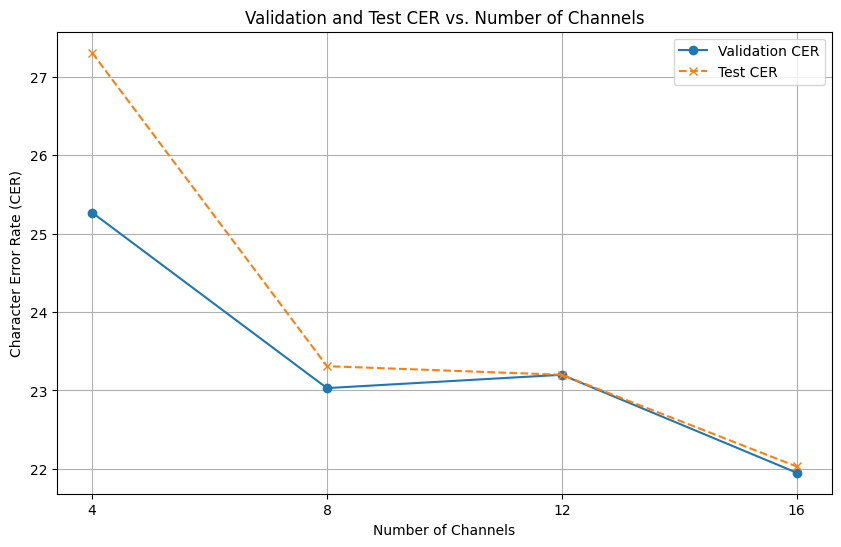

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Number of channels used in each experiment
num_channels = np.array([16, 8, 4, 12])

# Validation CER values for each experiment
val_cer = np.array([21.95, 23.03, 25.27, 23.2])

# Test CER values for each experiment
test_cer = np.array([22.03, 23.31, 27.31, 23.2])

# Sort data by number of channels for clear plotting
sort_indices = np.argsort(num_channels)
num_channels = num_channels[sort_indices]
val_cer = val_cer[sort_indices]
test_cer = test_cer[sort_indices]

plt.figure(figsize=(10, 6))
plt.plot(num_channels, val_cer, marker='o', linestyle='-', label='Validation CER')
plt.plot(num_channels, test_cer, marker='x', linestyle='--', label='Test CER')

plt.title('Validation and Test CER vs. Number of Channels')
plt.xlabel('Number of Channels')
plt.ylabel('Character Error Rate (CER)')
plt.xticks(num_channels) # Ensure ticks are at the channel numbers used
plt.grid(True)
plt.legend()
plt.show()